In [ ]:
import glob
import os

import pandas as pd
import numpy as np

import tifffile as tf
from tifffile import imread
from tifffile import imwrite

import skimage
from skimage.util import compare_images
from skimage import io, color, measure
from skimage.measure import regionprops
from skimage.measure import label as sk_label  # Renaming the label function to avoid conflicts

import matplotlib.pyplot as plt
import matplotlib

%load_ext autoreload
%autoreload 2
%matplotlib inline


In [ ]:
# Import images

merged_dir = '/Users/abamford/Desktop/Example_data/00_Batch20230223/D21/Denoised_drift_corrected'
merged_path = os.path.join(merged_dir,'*.tif') 
merged_files = glob.glob(merged_path)

In [ ]:
# Read images into list

merged_images = []

for file in denoised_files:
    image = imread(file)
    merged_images.append(image)

In [ ]:
# Extract denoised channel

denoised_images = []

for image in merged_images:
    denoised_img = image[:, 0]
    denoised_images.append(denoised_img)

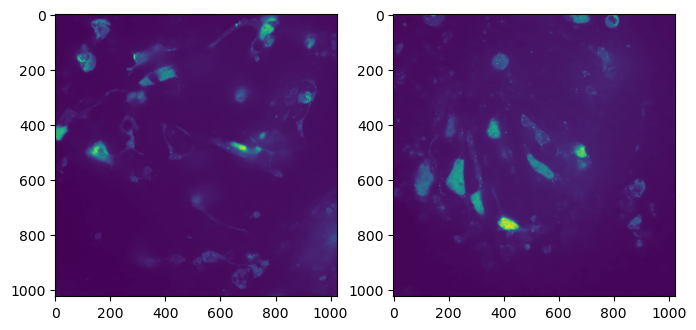

In [ ]:
# Plot loaded images

fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(denoised_images[3][0])
ax[1].imshow(denoised_images[4][0])

In [ ]:
# Create maximum projections of all images

max_project = []

for image in denoised_images:
    max_img = np.max(image, axis=0)
    max_project.append(max_img)

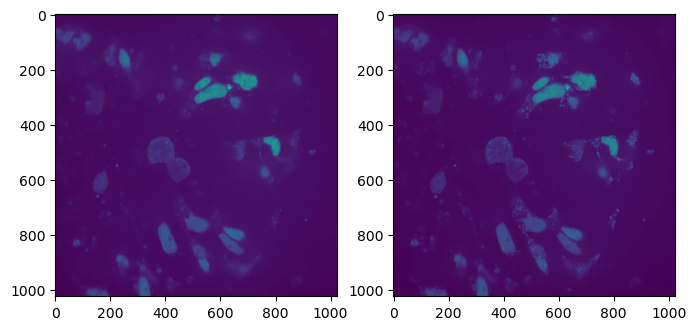

In [ ]:
# Plot first frame of series and max projection

fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(denoised_images[0][0])
ax[1].imshow(max_project[0])

In [ ]:
type(max_img)

numpy.ndarray

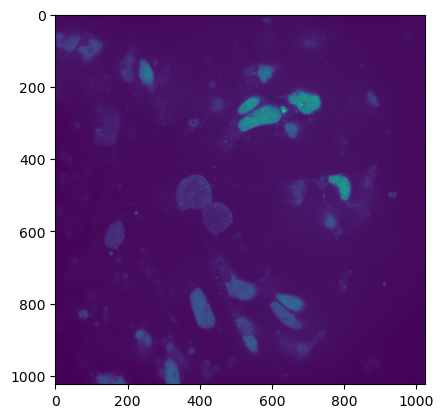

In [ ]:
# Create maximum projections of all images

single_slices = []

for image in denoised_images:
    single_slice = image[0,:]
    single_slices.append(single_slice)

plt.imshow(single_slices[0])

In [ ]:
# Save cytoplasm masks

max_proj_dir = '/Users/abamford/Desktop/Example_data/00_Batch20230223/D21/Single_slices'


In [ ]:
for img, tiff_file in zip(single_slices, merged_files):
    
    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    print(file_name)
    
    # Define the output file path
    output_file = os.path.join(max_proj_dir, file_name + '.tif')
    print(output_file)
    
    # Save the manipulated image as a TIFF
    tf.imwrite(output_file, img)

100tp_561-100-50ms-1000g_18_conf561_merged_xyCorrected
/Users/abamford/Desktop/Example_data/00_Batch20230223/D21/Single_slices/100tp_561-100-50ms-1000g_18_conf561_merged_xyCorrected.tif
100tp_561-100-50ms-1000g_5_conf561_merged_xyCorrected
/Users/abamford/Desktop/Example_data/00_Batch20230223/D21/Single_slices/100tp_561-100-50ms-1000g_5_conf561_merged_xyCorrected.tif
100tp_561-100-50ms-1000g_9_conf561_merged_xyCorrected
/Users/abamford/Desktop/Example_data/00_Batch20230223/D21/Single_slices/100tp_561-100-50ms-1000g_9_conf561_merged_xyCorrected.tif
100tp_561-100-50ms-1000g_23_conf561_merged_xyCorrected
/Users/abamford/Desktop/Example_data/00_Batch20230223/D21/Single_slices/100tp_561-100-50ms-1000g_23_conf561_merged_xyCorrected.tif
100tp_561-100-50ms-1000g_19_conf561_merged_xyCorrected
/Users/abamford/Desktop/Example_data/00_Batch20230223/D21/Single_slices/100tp_561-100-50ms-1000g_19_conf561_merged_xyCorrected.tif
100tp_561-100-50ms-1000g_15_conf561_merged_xyCorrected
/Users/abamford/Des